In [1]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [59]:
class BatsmanState(TypedDict):
    runs : int
    balls : int
    fours : int
    sixes : int
    strikerate : int
    boundarypercent : int
    ballsperboundary : int
    summary : str

In [68]:
def strikerate(state:BatsmanState)->BatsmanState:
    return {'strikerate':state['runs']/state['balls']}
def boundarypercent(state:BatsmanState)->BatsmanState:
    boundaryruns = state['fours']*4 + state['sixes']*6
    boundarypercent = (boundaryruns / 100) * state['runs']
    return {'boundarypercent':boundarypercent}
def ballsperboundary(state:BatsmanState)->BatsmanState:
    return {'ballsperboundary':(state['fours']+state['sixes'])/state['balls']}
def summary(state:BatsmanState)->BatsmanState:
    return {'summary' : 
            f"Here is the summary: Strike Rate:{state['strikerate']} \n BoundaryPercentage : {state['boundarypercent']} \n BallsPerBoundary:{state['ballsperboundary']}"}

In [69]:
graph = StateGraph(BatsmanState)
graph.add_node('strikerate',strikerate)
graph.add_node('boundarypercent',boundarypercent)
graph.add_node('ballsperboundary',ballsperboundary)
graph.add_node('summary',summary)
graph.add_edge(START,'strikerate')
graph.add_edge(START,'boundarypercent')
graph.add_edge(START,'ballsperboundary')
graph.add_edge('strikerate','summary')
graph.add_edge('boundarypercent','summary')
graph.add_edge('ballsperboundary','summary')
graph.add_edge('summary',END)

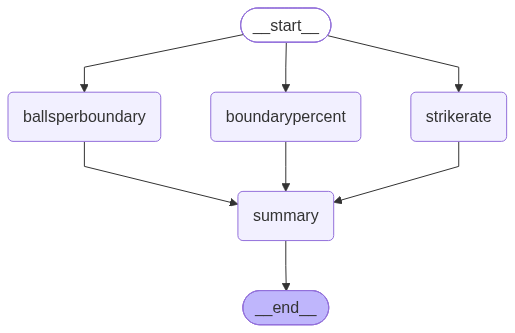

In [70]:
workflow = graph.compile()
workflow

In [71]:
initial_state = {
    'runs' : 28,
    'balls' : 6,
    'fours' : 4,
    'sixes' : 2
}
workflow.invoke(initial_state)

{'runs': 28,
 'balls': 6,
 'fours': 4,
 'sixes': 2,
 'strikerate': 4.666666666666667,
 'boundarypercent': 7.840000000000001,
 'ballsperboundary': 1.0,
 'summary': 'Here is the summary: Strike Rate:4.666666666666667 \n BoundaryPercentage : 7.840000000000001 \n BallsPerBoundary:1.0'}